# Домашнее задание 2 (10 баллов).

*Все задания ниже имеют равный вес*

Код для импорта мы написали за вас (не благодарите, нам не трудно). Дальше код будете писать вы. 

[Тут](https://habr.com/ru/companies/ruvds/articles/494720/) шпора по pandas. За основу домашнего задания взят ноутбук [отсюда](https://rutube.ru/video/f884aa6ed5f94120b7304506042fe5bb/) (не подглядывайте!).

In [103]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pprint import pprint

#### Описание данных

Автор д/з - плохой человек, который не стал переводить описание с мотивировкой, что весь DS на английском. Так что описание полей будет на английском:

1. Account ID
- Description: A unique identifier for each social media account in the dataset.
- Type: Integer
- Example: 1, 2, 3, …
2. Username
- Description: The username or handle of the social media account.
- Type: String
- Example: john_doe, tech_guru_22, fitness_freak
3. Platform
- Description: The social media platform the account is using (Instagram, Twitter, Facebook, TikTok, LinkedIn).
- Type: Categorical (String)
- Example: Instagram, Twitter, Facebook, TikTok, LinkedIn
4. Follower Count
- Description: The total number of followers the account has.
- Type: Integer
- Example: 1500, 245000, 78000
5. Posts Per Week
- Description: The average number of posts the account creates per week.
- Type: Integer
- Example: 3, 5, 7
6. Engagement Rate
- Description: The percentage of interactions (likes, comments, shares) relative to the follower count. This is a measure of how engaging the content is.
- Type: Float
- Range: 0.01 to 0.15
- Example: 0.045 (4.5% engagement rate)
7. Ad Spend (USD)
- Description: The monthly amount spent on advertising or promoting posts.
- Type: Float
- Example: 150.75, 850.00, 300.50
8. Conversion Rate
- Description: The percentage of users who take a desired action (e.g., clicking a link, signing up, etc.) after interacting with an ad.
- Type: Float
- Range: 0.01 to 0.05 (1% to 5% conversion rate)
- Example: 0.025 (2.5% conversion rate)
9. Campaign Reach
- Description: The total number of unique users reached by the user’s campaigns in a given month.
- Type: Integer
- Example: 5000, 20000, 15000

#### Задание 0

Подгрузите данные. Да-да, за чтение таблицы баллов не будет))

**Hint**: [pd.read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html)

In [104]:
df = pd.read_csv(
    "data.csv"
)
df.head()

,Account ID,Username,Platform,Follower Count,Posts Per Week,Engagement Rate,Ad Spend (USD),Conversion Rate,Campaign Reach
0,1,harrislisa,TikTok,54217,3,0.0986,538.10,0.0490,1308
1,2,rhicks,LinkedIn,987518,5,0.0834,479.24,0.0174,13302
2,3,qthomas,Facebook,218870,3,0.1020,150.36,0.0318,11043
3,4,carlosholt,Instagram,207432,6,0.0834,932.62,0.0400,12074
4,5,parsonsashley,Facebook,350204,2,0.0642,504.44,0.0463,14083


In [105]:
df = pd.read_csv("data.csv")

#### Задание 1

Колонка `Platform` содержит название различных платформ. Давайте представим, что в них есть некоторое отношение порядка. Закодируйте каждую платформу целым числом (от 0 до N) и положите этот "код" в новую колонку `Platform_Code`. Теперь вычислите корреляцию Спирмена между всеми парами колонок в датасете (результатом будет таблица корреляций). В качестве ответа выведите значение корреляции `Platform_Code` с `Engagement Rate`. Можете после вывода числа еще коротко написать, что оно означает (нет, это не оценивается).

**Hint**: [pd.factorize](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.factorize.html), [pd.DataFrame.select_dtypes](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.select_dtypes.html), [pd.DataFrame.corr](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html).

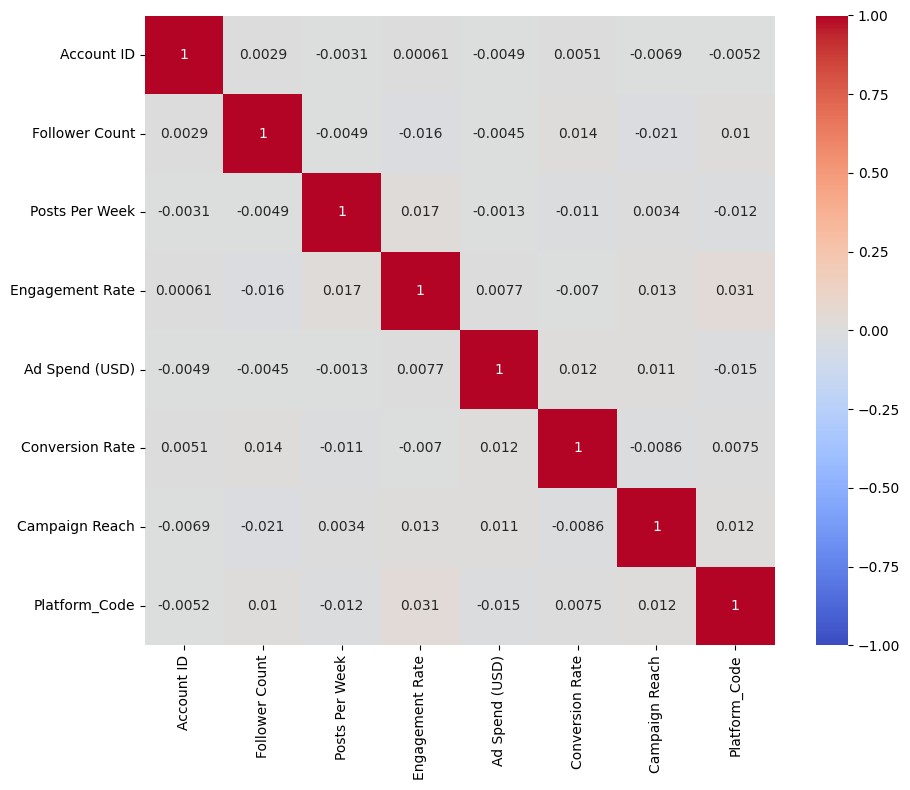

In [106]:
df["Platform_Code"] = pd.factorize(df["Platform"])[0]

df_selected = df.select_dtypes(exclude=["object"])

corr_matrix = df_selected.corr(method="spearman")

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True,       
            cmap='coolwarm',
            square=True,
            vmin=-1, 
            vmax=1
) 

plt.tight_layout()
plt.show()



In [107]:
corr_matrix.loc[
    "Platform_Code",
    "Engagement Rate"
]

np.float64(0.03138169529349812)

# Выводы

- По диагонали признак кореллирует сам с собой
- Сильной корелляции не наблюдается => линейной зависимости между признаками нет
- Также, так как использована корелляция Спирмена, то и монотонной зависимости нет
- Это тем не менне не отменяет того факта что зависимость может быть нелинейной, требуется 

#### Задание 2

Теперь посмотрите на столбец `Follower Count`. В нем какие-то числа. Иногда бывает полезно провести дискретизацию такого признака. Разбейте все значения в столбце на 4 группы: "Low", "Medium", "High", "Very High". Каждая группа включает в себя новые 25% данных. То есть, Low включает в себя 25% самых маленьких значений признака и так далее. Положите значения "Low", "Medium", "High" или "Very High" для каждого сэмпла датасета в новую колонку `Follower_Bin`. Теперь посчитайте среднее значение `Engagement Rate` для каждой категории из `Follower_Bin`. В качестве ответа выведите значение для категории "High".

**Hint**: [pd.qcut](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html), [pd.groupby](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html), [pd.DataFrame.mean](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.mean.html)

In [108]:
df["Follower_Bin"] = pd.qcut(
    df["Follower Count"],
    q = 4,
    labels=[
        "Low",
        "Medium",
        "High", 
        "Very High"
    ]
)

res = df.groupby("Follower_Bin")["Engagement Rate"].mean()

float(res.loc["High"])

0.08655032

#### Задание 3

Иногда бывает полезно превратить широкую таблицу в длинную (например, для визуализаций сразу нескольких признаков на одной картинке). Да, звучит странно, но именно этим вы сейчас и займетесь. Сделайте новый датафрейм `melted_df`, в который вы поместите каждый сэмпл датасета 6 раз: по одному разу на значение из 'Follower Count', 'Posts Per Week', 'Ad Spend (USD)', 'Conversion Rate', 'Engagement Rate' и 'Campaign Reach'. То есть, вы берете сэмпл из датасета (строку) и превращаете ее в 6 отдельных строк. Каждая отдельная строка в столбце `Metric` имеет имя из предложенного списка 5 признаков, а в столбце `Value` - значение данного сэмпла по этому признаку. Значение `Platform` повторяется в этих 6 строках.

Иначе говоря, 

```json
{
    "Account ID": 1,
    "Username": "harrislisa",
    "Platform": "TikTok",
    "Follower Count": 54217,
    "Posts Per Week": 3,
    "Engagement Rate": 0.0986,
    "Ad Spend (USD)": 538.1,
    "Conversion Rate": 0.049,
    "Campaign Reach": 1308,
    "Platform_Code": 0,
    "Follower_Bin": "Low"
}
```

превращается в 

```json
{
    "Platform": "TikTok",
    "Metric": "Follower Count",
    "Value": 54217,
},
{
    "Platform": "TikTok",
    "Metric": "Posts Per Week",
    "Value": 3,
}, ...
```

Для каждого уникальной пары значений (`Platform`, `Metric`) посчитайте моду среди всех значений `Value` для этой пары, результат сделайте списком и оставьте только наибольшее. В качестве ответа выведите сумму полученных мод (сумму всех значений в столбце `Value` уже после вычисления мод). Иначе говоря, выведите сумму всех мод значений для всех уникальных пар (`Platform`, `Metric`).

**Hint**: [pd.melt](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.melt.html), [pd.DataFrame.mode](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.mode.html), [pd.DataFrameGroupBy.agg](https://pandas.pydata.org/docs/dev/reference/api/pandas.core.groupby.DataFrameGroupBy.agg.html)

In [109]:

targets = [
    'Follower Count',
    'Conversion Rate', 
    'Engagement Rate',  
    'Posts Per Week', 
    'Ad Spend (USD)', 
    'Campaign Reach'
]

melted_df = pd.melt(
    df,
    id_vars=['Platform'],
    value_vars=targets,
    var_name='Metric',
    value_name='Value' 
)

modes_df = melted_df.groupby(
    [
        'Platform', 
        'Metric'
    ]
)['Value'].agg(
    lambda x: x.mode().max()
).reset_index()

result = modes_df['Value'].sum()
float(result)

3100285.4716

In [110]:
pprint(df.columns)

Index(['Account ID', 'Username', 'Platform', 'Follower Count',
       'Posts Per Week', 'Engagement Rate', 'Ad Spend (USD)',
       'Conversion Rate', 'Campaign Reach', 'Platform_Code', 'Follower_Bin'],
      dtype='str')


#### Задание 4

А теперь хочется посмотреть на самые популярные аккаунты на разных платформах. Для каждой платформы отсортируйте датафрейм по убыванию количества подписчиков (`Follower Count`) - да, без циклов, сразу для всех платформ сделать сортировку, а затем оставьте только первые три записи для каждой платформы - это и будут три самых популярных аккаунта для каждой платформы. В качестве ответа выведите саму таблицу и минимальное значение `Follower Count` в ней.

**Hint**: к *groupby* можно применять функции - это эквивалентно применению функции к каждой "группе" внутри groupby-объекта. Читайте [про применение apply к датафрейму после groupby](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html#flexible-apply).

In [111]:
df_top3 = (
    df.groupby('Platform', group_keys=False)
    .apply(lambda x: x.sort_values('Follower Count', ascending=False).head(3))
    .reset_index(drop=True)
)

df_top3.head(15)

,Account ID,Username,Follower Count,Posts Per Week,Engagement Rate,Ad Spend (USD),Conversion Rate,Campaign Reach,Platform_Code,Follower_Bin
0,2404,eric65,999982,6,0.0642,884.06,0.0281,17312,2,Very High
1,7351,patricknoble,997915,3,0.0834,429.01,0.0182,25985,2,Very High
2,1690,chavezjason,997512,7,0.0834,993.20,0.0397,45717,2,Very High
3,8686,alexandersamuel,999726,3,0.0834,687.61,0.0205,11050,3,Very High
4,3966,lrodgers,999351,1,0.0834,565.07,0.0335,12391,3,Very High
5,2190,jbrown,997844,5,0.0642,505.61,0.0202,14717,3,Very High
6,3040,toneill,999055,4,0.0642,799.49,0.0174,21862,1,Very High
7,6360,andrewgregory,998968,7,0.1020,797.64,0.0351,15552,1,Very High
8,2160,ashleycooper,998925,6,0.0856,474.46,0.0156,45956,1,Very High
9,5839,edwardthomas,999739,7,0.0642,630.77,0.0325,35523,0,Very High


In [112]:
min_followers = df_top3['Follower Count'].min()
print(min_followers)

997512


#### Задание 5

Хочется посчитать какую-то метрику. Мы хотим посмотреть, на отношение разности суммы подписчиков аккаунтов с высокой и низкой конверсией к суммарному охвату рекламы на каждой платформе. То есть, мы делим аккаунты на две группы: высокая и низка конверсия. Затем мы смотрим на то, на сколько сильно влияние аккаунтов с высокой конверсией по сравнению с аккаунтами с низкой конверсией. 

Давайте определим *Conversion Influence* следущим образом:

$$Conversion Influence = \frac{Total Follower\ Count (High) - Total Follower\ Count (Low)}{Total Campaign Reach (High)+Total Campaign Reach (Low)}$$

Считать эту метрику мы будет для каждой `Platform`. В этой формуле High - это значения всех сэмплов датасета, в которых `Conversion Rate` больше медианы, а `Low` - не более медианы. `Total Feature` - это суммарное количество значений `Feature` либо по `High` сэмплам, либо по `Low`.

Чтобы постоянно не пересчитывать, где High. где Low, сделайте новую колонку в датасете `Conversion_Category`. Положите в нее для каждой строки либо High, либо Low.

Выведите платформу с самым большим `Conversion Influence`.

**Hint**: данное задание не про *groupby*, а скорее про [pd.pivot_table](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html). Сделайте сводную таблицу, по которой уже можно посчитать суммы, а затем подставить их в формулы.

In [113]:

med_conv = df['Conversion Rate'].median()

df['Conversion_Category'] = df['Conversion Rate'].apply(
    lambda x: 'High' if x > med_conv else 'Low'
)

df.head()

,Account ID,Username,Platform,Follower Count,Posts Per Week,Engagement Rate,Ad Spend (USD),Conversion Rate,Campaign Reach,Platform_Code,Follower_Bin,Conversion_Category
0,1,harrislisa,TikTok,54217,3,0.0986,538.10,0.0490,1308,0,Low,High
1,2,rhicks,LinkedIn,987518,5,0.0834,479.24,0.0174,13302,1,Very High,Low
2,3,qthomas,Facebook,218870,3,0.1020,150.36,0.0318,11043,2,Low,High
3,4,carlosholt,Instagram,207432,6,0.0834,932.62,0.0400,12074,3,Low,High
4,5,parsonsashley,Facebook,350204,2,0.0642,504.44,0.0463,14083,2,Medium,High


In [114]:
pivoted_df = df.pivot_table(
    aggfunc='sum',
    columns='Conversion_Category',
    values=[
        'Follower Count', 
        'Campaign Reach'
    ],
    index='Platform',
)

In [115]:

follower_diff = (
    pivoted_df[(
        'Follower Count', 
        'High')
    ] - 
    pivoted_df[(
        'Follower Count', 
        'Low')
    ]
)


total_reach = pivoted_df[
    (
    'Campaign Reach', 
    'High'
    )
    ] + pivoted_df[
        (
        'Campaign Reach', 
        'Low'
        )
    ]


conversion_influence = follower_diff / total_reach.replace(0, pd.NA)

In [116]:
max_platform = conversion_influence.dropna().idxmax()
max_value = conversion_influence.dropna().max()

In [117]:
max_platform

'Twitter'

In [118]:
float(max_value)

1.0908724546727178

#### Задание 6

Мы знаем, что вам понравилось считать метрики по формуле. Давайте закрепим этот успех. Теперь для каждой платформы посчитаем, на сколько эффективна реклама в разрезе трех последовательных записей в датасете. 

Для каждой платформы отсортируйте записи в порядке убывания `Posts Per Week`. Будто бы аккаунты, которые постят чаще, используют более "активные" стратегии по рекламе. Теперь посчитайте *скользущие суммы с окном 3* по `Campaign Reach` и `Ad Spend (USD)`. Скользящая сумма с окном N - это вы идете по массиву, берете все последовательные тройки записей и суммируете их. Для первых двух записей троек не найдется. Для них скользящее среднее - NaN, что нам не помешает. 

Теперь для каждого окна посчитайте 

$$Rolling Efficiency Ratio = \frac{Rolling Sum of Campaign Reach}{Rolling Sum of Ad Spend}$$

По сути, для каждого окна вы посчитаете сколько пользователе привлеклось за один доллар, потреченный на рекламу, в данном окне. Понятно, что значений будет столько, сколько окон. Нам интересно максимально значение такой эффективности для каждой платформы.

В качестве ответа выведите название платформы с наибольшей максимальной эффективность и наименьшей (два названия, не одно, не три, ровно два).

**Hint**: окна можно делать через [pd.DataFrame.rolling](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html).

In [119]:
df_sorted = df.sort_values(
    [
        'Platform', 
        'Posts Per Week'
    ],
    ascending=[
        True, 
        False
    ]
)

In [120]:
roll_sums = df_sorted.groupby(
    'Platform'
)[[
    'Campaign Reach', 
    'Ad Spend (USD)'
]].rolling(window=3).sum()


roll_sums.head()

rolling_df = roll_sums.reset_index()
rolling_df['Efficiency'] = rolling_df['Campaign Reach'] / rolling_df['Ad Spend (USD)']

max_efficiency = rolling_df.groupby(
    'Platform'
)[
    'Efficiency'
].max().dropna()

platform_max = max_efficiency.idxmax()
platform_min = max_efficiency.idxmin()

In [121]:
platform_max

'Facebook'

In [122]:
platform_min

'TikTok'

#### Задание 7

Это еще не все прекрасные функции pandas, которые мы хотим вам показать. Теперь вы посчитаете, сколько аккаунтов на каждой платформе одновременно лучшие по `Engagement Rate` и `Conversion Rate`.

Сделайте два отдельных суб-сета. В одном оставьте для каждой платфмормы один топовый аккаунт по `Engagement Rate`, в другом - по `Conversion Rate`. Соедините эти два подмножества по столбцу `Platform` так, что в одно строке есть описание сразу двух аккаунтов-лидеров. Теперь посмотрите равны ли имена аккаунтов в одной строке. Выведите количество строк, в которых названия аккаунтов совпадают.

In [123]:

top_engagement = df.sort_values([
    'Platform', 
    'Engagement Rate'
], ascending=[
    True, 
    False
]).groupby(
    'Platform'
).first().reset_index()



top_engagement.head()

,Platform,Account ID,Username,Follower Count,Posts Per Week,Engagement Rate,Ad Spend (USD),Conversion Rate,Campaign Reach,Platform_Code,Follower_Bin,Conversion_Category
0,Facebook,3,qthomas,218870,3,0.102,150.36,0.0318,11043,2,Low,High
1,Instagram,60,jaimeedwards,521857,6,0.102,902.41,0.0328,46702,3,High,High
2,LinkedIn,73,allen72,595994,6,0.102,933.92,0.0381,42791,1,High,High
3,TikTok,23,carlosholt,693593,5,0.102,779.45,0.0208,4053,0,High,Low
4,Twitter,95,marquezedward,487293,1,0.102,852.45,0.0310,32055,4,Medium,High


In [124]:
top_conversion = df.sort_values([
    'Platform', 
    'Conversion Rate'
], ascending=[
    True, 
    False
]).groupby(
    'Platform'
).first().reset_index()


top_conversion.head()

,Platform,Account ID,Username,Follower Count,Posts Per Week,Engagement Rate,Ad Spend (USD),Conversion Rate,Campaign Reach,Platform_Code,Follower_Bin,Conversion_Category
0,Facebook,3465,michael55,244081,3,0.0834,313.49,0.05,37596,2,Low,High
1,Instagram,2864,aprilwilliams,222951,4,0.0986,767.52,0.05,45634,3,Low,High
2,LinkedIn,8017,jeff87,816658,1,0.0856,986.41,0.05,22822,1,Very High,High
3,TikTok,285,robertmorris,702687,1,0.0856,276.36,0.05,2250,0,High,High
4,Twitter,5993,trobinson,500601,5,0.1020,611.10,0.05,35814,4,Medium,High


In [125]:
merged = pd.merge(
    top_engagement[['Platform', 'Username', 'Engagement Rate']],
    top_conversion[['Platform', 'Username', 'Conversion Rate']],
    on='Platform',
    how='inner',
    suffixes=('_eng', '_conv')
)

merged.head()

,Platform,Username_eng,Engagement Rate,Username_conv,Conversion Rate
0,Facebook,qthomas,0.102,michael55,0.05
1,Instagram,jaimeedwards,0.102,aprilwilliams,0.05
2,LinkedIn,allen72,0.102,jeff87,0.05
3,TikTok,carlosholt,0.102,robertmorris,0.05
4,Twitter,marquezedward,0.102,trobinson,0.05


In [126]:
result = (merged['Username_eng'] == merged['Username_conv']).sum()

pprint(result)

np.int64(0)


#### Задание 8

Давайте теперь что-то попроще сделаем. Например, посчитаем отношение суммарного количества подписчиков на аккаунтах с высокой конверсией к такой же сумме в аккаунтах с низкой конверсией (очевидно, для каждой платформы). По сути, мы просто хотим получить число, которое характеризует, на сколько сильно аккаунты с высокой конверсией "доминируют" над аккаунтами с низкой конверсией в плане количества подписчиков.

Высокой конверсией будем считать конверсию больше средней. Остальное - низкая. Посчитайте суммы подписчиков для каждой платформы, поделите одно на другое и выведите разницу между самым большим значением и самым маленьким, а также платформы, которые соотвутствуют этим значениям.

Используйте магическую команду `%%time`, чтобы замерить, сколько времени ушло на исполнение вашего pandas-скрипта.

In [127]:
mean_conv = df['Conversion Rate'].mean()

df['Conversion_Category'] = df[
    'Conversion Rate'
].apply(
    lambda x: 'High' if x > mean_conv else 'Low'
)

df.head()

,Account ID,Username,Platform,Follower Count,Posts Per Week,Engagement Rate,Ad Spend (USD),Conversion Rate,Campaign Reach,Platform_Code,Follower_Bin,Conversion_Category
0,1,harrislisa,TikTok,54217,3,0.0986,538.10,0.0490,1308,0,Low,High
1,2,rhicks,LinkedIn,987518,5,0.0834,479.24,0.0174,13302,1,Very High,Low
2,3,qthomas,Facebook,218870,3,0.1020,150.36,0.0318,11043,2,Low,High
3,4,carlosholt,Instagram,207432,6,0.0834,932.62,0.0400,12074,3,Low,High
4,5,parsonsashley,Facebook,350204,2,0.0642,504.44,0.0463,14083,2,Medium,High


In [128]:
follower_sums = df.groupby([
    'Platform', 
    'Conversion_Category'
])['Follower Count'].sum().unstack()

follower_sums['Ratio'] = follower_sums['High'] / follower_sums['Low']

follower_sums.head()

Conversion_Category,High,Low,Ratio
Platform,,,
Facebook,491799506,520352686,0.945127
Instagram,468232352,544465076,0.859986
LinkedIn,490706904,518510323,0.946378
TikTok,482930355,504080020,0.958043
Twitter,518386631,499951697,1.036873


In [129]:
max_ratio = follower_sums['Ratio'].max()
min_ratio = follower_sums['Ratio'].min()

platform_max = follower_sums['Ratio'].idxmax()
platform_min = follower_sums['Ratio'].idxmin()

difference = max_ratio - min_ratio

In [130]:
float(difference)

0.17688741338715763

In [131]:
print(f'максимальная платформа {platform_max}')

максимальная платформа Twitter


In [132]:
print(f'максимальная платформа {platform_min}')

максимальная платформа Instagram


Полный код:

In [133]:
%%time

mean_conv = df['Conversion Rate'].mean()

df['Conversion_Category'] = df[
    'Conversion Rate'
].apply(
    lambda x: 'High' if x > mean_conv else 'Low'
)

follower_sums = df.groupby([
    'Platform', 
    'Conversion_Category'
])['Follower Count'].sum().unstack()

follower_sums['Ratio'] = follower_sums['High'] / follower_sums['Low']

max_ratio = follower_sums['Ratio'].max()
min_ratio = follower_sums['Ratio'].min()

platform_max = follower_sums['Ratio'].idxmax()
platform_min = follower_sums['Ratio'].idxmin()

difference = max_ratio - min_ratio

CPU times: user 4.12 ms, sys: 1.33 ms, total: 5.44 ms
Wall time: 4.52 ms


In [134]:
print(difference)
print(f'максимальная платформа {platform_max}')
print(f'максимальная платформа {platform_min}')

0.17688741338715763
максимальная платформа Twitter
максимальная платформа Instagram


#### Задание 9

А теперь решите задание 8 чисто питоном. Никаких функций и методов pandas. Только питоновские циклы. Замерьте время выполнения кода. Наконец, сравните время в задании 8 и 9. Напишите ниже, кто же победил: чистый python и pandas?

**Hint**: Чтобы итерироваться по датафрейму, можно из него сделать генератор через [pd.DataFrame.iterrows](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iterrows.html) или [pd.DataFrame.itertuples](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.itertuples.html#pandas.DataFrame.itertuples). К слову, это не все способы итерироваться по датафрейму.

In [135]:
%%time

total_conv = 0
count = 0
for index, row in df.iterrows():
    total_conv += row['Conversion Rate']
    count += 1
mean_conv = total_conv / count

follower_sums_dict = {}

for index, row in df.iterrows():
    platform = row['Platform']
    conv_rate = row['Conversion Rate']
    follower_count = row['Follower Count']
    category = 'High' if conv_rate > mean_conv else 'Low'
    key = (platform, category)

    if key not in follower_sums_dict:
        follower_sums_dict[key] = 0
    follower_sums_dict[key] += follower_count


platforms = set()
for key in follower_sums_dict:
    platforms.add(key[0])

results = {}

for platform in platforms:
    high_sum = follower_sums_dict.get((platform, 'High'), 0)
    low_sum = follower_sums_dict.get((platform, 'Low'), 0)

    if low_sum > 0:
        ratio = high_sum / low_sum
        results[platform] = ratio

max_ratio = float('-inf')
min_ratio = float('inf')
platform_max = None
platform_min = None

for platform, ratio in results.items():
    if ratio > max_ratio:
        max_ratio = ratio
        platform_max = platform

    if ratio < min_ratio:
        min_ratio = ratio
        platform_min = platform

difference = max_ratio - min_ratio
pprint(difference)

0.17688741338715763
CPU times: user 303 ms, sys: 10.4 ms, total: 313 ms
Wall time: 366 ms


In [136]:
print(difference)
print(f'максимальная платформа {platform_max}')
print(f'максимальная платформа {platform_min}')

0.17688741338715763
максимальная платформа Twitter
максимальная платформа Instagram


**А победителем является**: Pandas

#### Задание 10

Крайне серьезное задание. Отнеситесь к нему соответствующе. В ячейке ниже напишите ваш любимый анекдот или мем (только без баянов, окей?). Можно плохие. Помните, это задание на полный балл. Проверяющий работу ассистент должен улыбнуться.

Если вставляете картинку, то убедитесь, что вы ее не подгружаете локально. А то будет неудобно - потерять балл на этом задании, когда надо было выложить картинку на облако и прокинуть ссылку. И нет, нельзя сюда просто ссылку вставить. Либо ищите, как вставить картинку, либо смешной анекдот. Есть всего два стула - выбирайте...

Решил генерал попить чая, отправил майора заваривать. Майор думает:
- Че я буду сам чай заваривать, я же целый МАЙОР, дай ка вон рядового напрягу. Пожходит к рядовому и говорит, мол иди завари генералу чай. Рядовому в лом чай заваривать, он переворачивает кружку вверх дном и говорит:
- Товарищ майор, а у кружки горлышко запаяно
- Как запаяно?
- Не могу знать, товарища майор

Идут генералу, показывают кружку
- Где мой чай, майор?
- Виноват, товарищ генерал, у кружки горлышко запаяно
Генерал крутит кружку в руках и говорит:
- Какие же вы все таки идиоты, у нее еще и дна нет...